In [4]:
import pandas as pd 
import numpy as np 
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
%cd "C:\Users\amatk\OneDrive\Dokumenty\2_Tuebingen\SoSe_26\Speaker-Recognition-using-ResNet-Embeddings\preds"

C:\Users\amatk\OneDrive\Dokumenty\2_Tuebingen\SoSe_26\Speaker-Recognition-using-ResNet-Embeddings\preds


In [6]:
NUM_CLASSES = 50

## Define Functions

In [7]:
def show_highest_confusion(cm, n_display):
    errors = []
    
    for true_class in range(NUM_CLASSES):
        for pred_class in range(NUM_CLASSES):
            if true_class != pred_class:
                errors.append(
                    {
                        "True class" :true_class,
                        "Predicted class": pred_class,
                        "Confusion" : cm[true_class, pred_class]
                    }
                )
    
    df_errors = pd.DataFrame(errors)
    df_errors = df_errors.sort_values(by="Confusion", ascending = False)
    return df_errors.head(n_display).reset_index(drop=True)

In [8]:
def display_highest_confidence(df):
    df.sort_values(by="Confidence", ascending=False).head(10)

In [9]:
def show_highest_confidence_false_pred(df, display_n):
    wrong = df[~df.Correct].copy()

    return wrong.sort_values(by="Confidence", ascending=False).head(display_n).reset_index(drop=True)


In [10]:
def avg_correct_pred_per_class(df):
    per_class = df.groupby("True")["Correct"].mean().sort_values()
    
    per_class.name = "mean"

    return per_class

In [11]:
def plot_confidence_histogram(df):
    plt.hist(df[df.Correct]["Confidence"],
         bins=30,
         alpha=0.6,
         label="Correct")

    plt.hist(df[~df.Correct]["Confidence"],
         bins=30,
         alpha=0.6,
         label="Wrong")

    plt.legend()
    plt.xlabel("Prediction confidence")
    plt.ylabel("Count")
    plt.show()

## Load Datasets

In [54]:
data_1s = pd.read_csv("predictions_1sec.csv")
data_2s = pd.read_csv("predictions_2sec.csv")
data_4s = pd.read_csv("predictions_4sec.csv")
data_c = pd.read_csv("predictions_contr.csv")
data_base = pd.read_csv("predictions_baseline.csv")

In [55]:
labels_4s = list(data_4s["True"])
preds_4s = list(data_4s["Pred"])

labels_2s = list(data_2s["True"])
preds_2s = list(data_2s["Pred"])

labels_1s = list(data_1s["True"])
preds_1s = list(data_1s["Pred"])

labels_c = list(data_c["True"])
preds_c = list(data_c["Pred"])

labels_base = list(data_base["True"])
preds_base = list(data_base["Pred"])

In [56]:
cm_4s = confusion_matrix(labels_4s, preds_4s, normalize="true")

cm_2s = confusion_matrix(labels_2s, preds_2s, normalize="true")

cm_1s = confusion_matrix(labels_1s, preds_1s, normalize="true")

cm_c = confusion_matrix(labels_c, preds_c, normalize="true")

cm_b = confusion_matrix(labels_base, preds_base, normalize="true")

## Average confidence plot

In [57]:
avg_1 = avg_correct_pred_per_class(data_1s)
avg_2 = avg_correct_pred_per_class(data_2s)
avg_4 = avg_correct_pred_per_class(data_4s)
avg_c = avg_correct_pred_per_class(data_c)
avg_b = avg_correct_pred_per_class(data_base)

In [58]:
df_averages = pd.concat(
    {
        "Baseline": avg_b,
        "Model 1s": avg_1, 
        "Model 2s": avg_2, 
        "Model 4s": avg_4, 
        "Model c": avg_c
    }, 
    axis=1
)

In [59]:
# Convert index (class labels) to a column, then melt the columns into rows
df_long = df_averages.reset_index().melt(
    id_vars="True", 
    var_name="Model",  # Column name for the models
    value_name="Average_Correctness",  # Column name for the values
)

In [60]:
# make sure colors stay consistent
muted_palette = sns.color_palette("muted", 5)

model_colors = {
    "Model 1s": muted_palette[0],  
    "Model 2s": muted_palette[1], 
    "Model 4s": muted_palette[2],
    "Model c": muted_palette[3], 
    "Baseline": muted_palette[4]
}

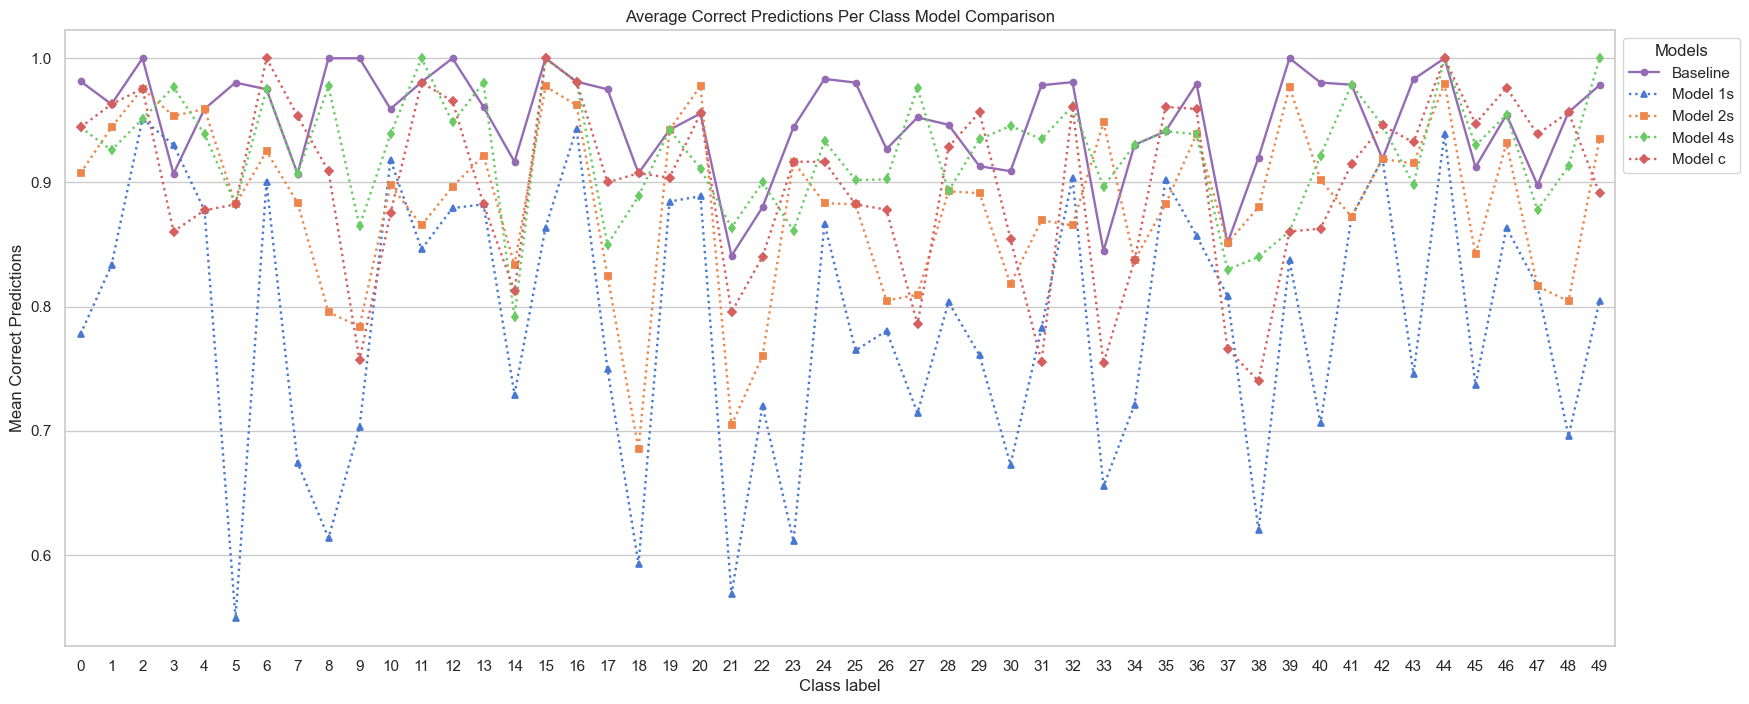

In [61]:
plt.figure(figsize=(20,8))
sns.pointplot(
    data = df_long, 
    x="True",
    y="Average_Correctness",
    hue = "Model", 
    palette=model_colors,
    markers=["o", "^", "s", "d", "D"], # Different shapes per model
    linestyles=["-", ":", ":", ":", ":"], 
    lw = 1.7
)

plt.ylabel("Mean Correct Predictions")
plt.xlabel("Class label")
plt.title("Average Correct Predictions Per Class Model Comparison")
plt.legend(title="Models", bbox_to_anchor=(1, 1), loc = 'upper left')
# plt.tight_layout()
plt.show()

## Highest confusion

In [62]:
df_conf_1s = show_highest_confusion(cm_1s, 5)
df_conf_2s = show_highest_confusion(cm_2s, 5)
df_conf_4s = show_highest_confusion(cm_4s, 5)
df_conf_c = show_highest_confusion(cm_c, 5)
df_conf_base = show_highest_confusion(cm_b, 5)

In [63]:
df_conf_1s["Model"] = "Model 1s"
df_conf_2s["Model"] = "Model 2s"
df_conf_4s["Model"] = "Model 4s"
df_conf_c["Model"] = "Model c"
df_conf_base["Model"] = "Baseline"

In [64]:
for df in [df_conf_1s, df_conf_2s, df_conf_4s, df_conf_c, df_conf_base]:
    df["Error pair"] = df["True class"].astype(str) + " -> " + df["Predicted class"].astype(str)

In [65]:
df_all_errors = pd.concat([df_conf_1s, df_conf_2s, df_conf_4s, df_conf_c, df_conf_base], axis=0)
df_all_errors = df_all_errors.sort_values(by = "Confusion", ascending= False)

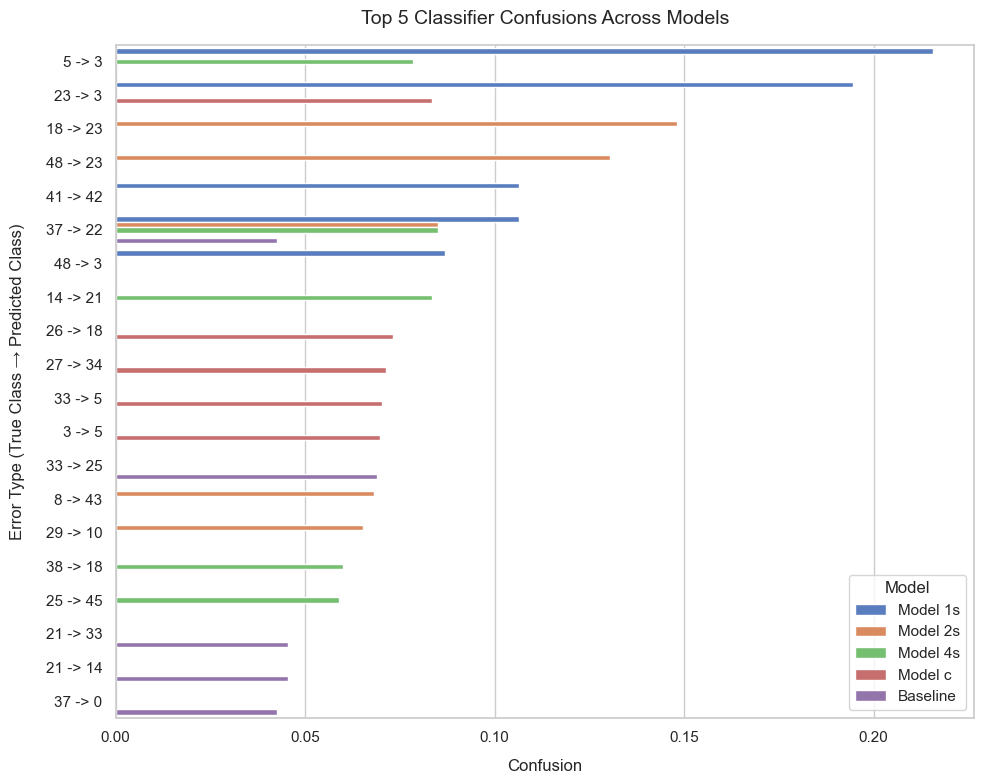

In [66]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

# Plotting horizontal bars grouped by Model
sns.barplot(
    data=df_all_errors,
    y="Error pair",
    x="Confusion",
    hue="Model",
    palette=model_colors
)

plt.title("Top 5 Classifier Confusions Across Models", fontsize=14, pad=15)
plt.xlabel("Confusion", labelpad=10)
plt.ylabel("Error Type (True Class → Predicted Class)", labelpad=15)
plt.tight_layout()
plt.show()

## Highest confidence with wrong prediction

In [30]:
confidence_1s = show_highest_confidence_false_pred(data_1s, 5)
confidence_2s = show_highest_confidence_false_pred(data_2s, 5)
confidence_4s = show_highest_confidence_false_pred(data_4s, 5)
confidence_c = show_highest_confidence_false_pred(data_c, 5)

In [31]:
confidence_1s["Model"] = "Model 1s"
confidence_2s["Model"] = "Model 2s"
confidence_4s["Model"] = "Model 4s"
confidence_c["Model"] = "Model c"

In [32]:
for df in [confidence_1s, confidence_2s, confidence_4s, confidence_c]:
    df.drop(columns=["Correct"])
    df["Error pair"] = df["True"].astype(str) + " -> " + df["Pred"].astype(str)

In [33]:
df_all_conf = pd.concat([confidence_1s, confidence_2s, confidence_4s, confidence_c], axis=0)
df_all_conf = df_all_conf.sort_values(by = "Confidence", ascending= False)

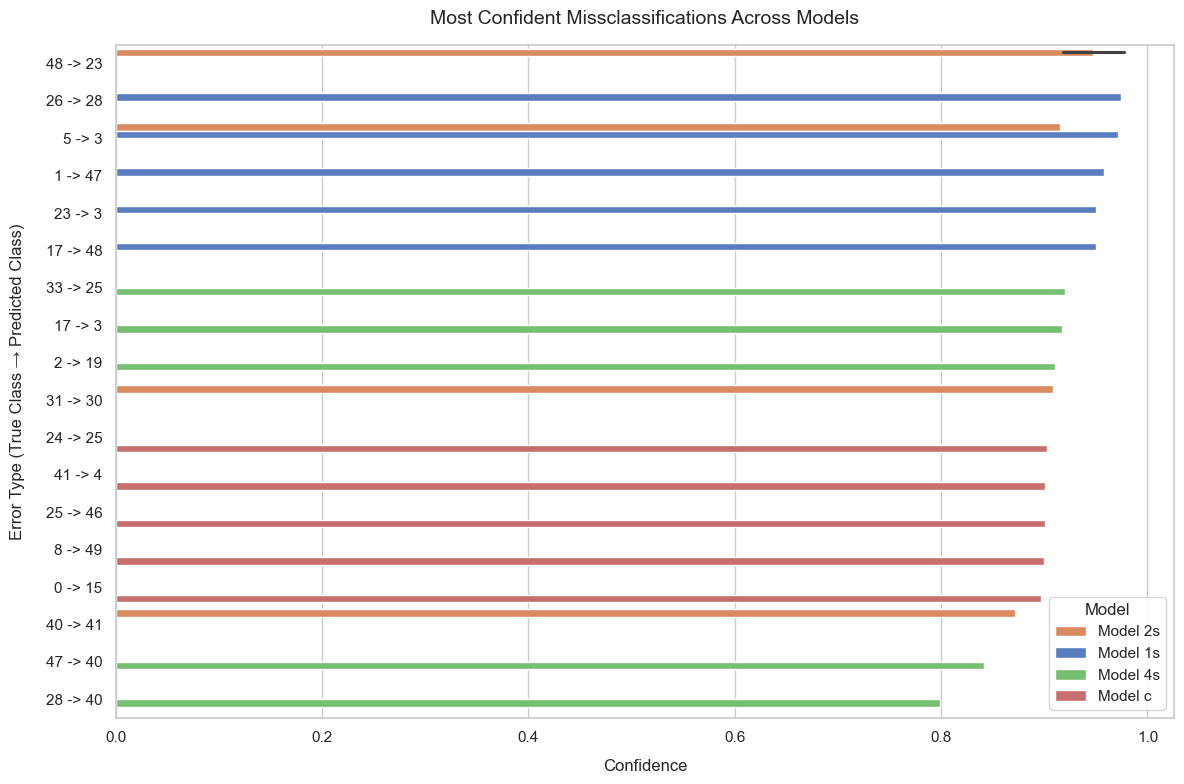

In [35]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Plotting horizontal bars grouped by Model
sns.barplot(
    data=df_all_conf,
    y="Error pair",
    x="Confidence",
    hue="Model",
    palette=model_colors
)

plt.title("Most Confident Missclassifications Across Models", fontsize=14, pad=15)
plt.xlabel("Confidence", labelpad=10)
plt.ylabel("Error Type (True Class → Predicted Class)", labelpad=15)
plt.tight_layout()
plt.show()

## Confidence histogram

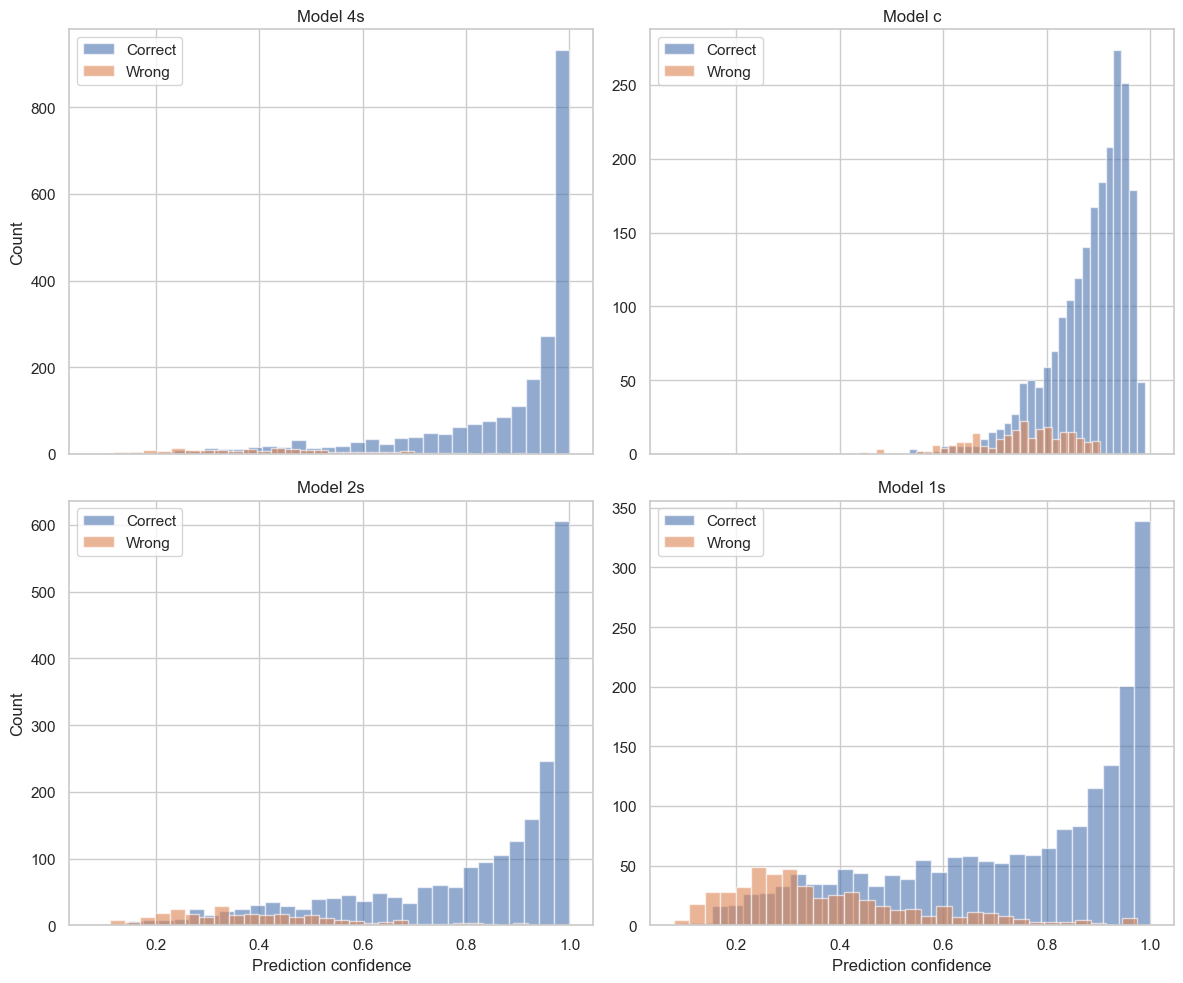

In [36]:
model_names = ["Model 4s", "Model c", "Model 2s", "Model 1s"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

axes_flat = axes.flatten()
dataframes = [data_4s, data_c, data_2s, data_1s]

for i, (df, ax, name) in enumerate(zip(dataframes, axes_flat, model_names)):
    ax.hist(
        df[df.Correct]["Confidence"],
        bins=30,
        alpha=0.6,
        label="Correct")

    ax.hist(
        df[~df.Correct]["Confidence"],
        bins=30,
        alpha=0.6,
        label="Wrong")

    ax.set_title(name)
    ax.legend(loc="upper left")
    
    #set labels on the outer edges
    if i >= 2:
        ax.set_xlabel("Prediction confidence")
    if i % 2 == 0: 
        ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

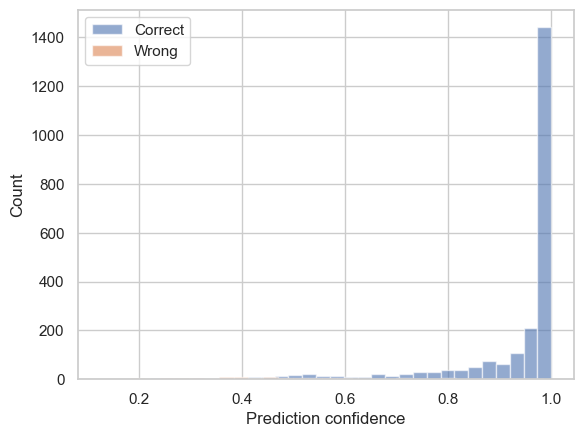

In [53]:
plot_confidence_histogram(data_base)